# 03. Likelihood and Maximum Likelihood

Notebook 02 studied the **sampling distribution of estimators**. We change perspective. Once we posit a statistical model, the observed data induce a **likelihood function** over parameter values. Likelihood turns the sample from a collection of observations into an evidence-ranking device.

That shift is foundational for modern statistics. Maximum likelihood estimation (MLE) underlies generalized linear models, survival models, time-series models, hierarchical models, and much of machine learning. In decision science, likelihood matters because many high-stakes workflows require us to compare competing risk levels, operating assumptions, or model configurations using the evidence actually observed.

We develop likelihood in a concrete operational setting. We will study enterprise support tickets, use a Bernoulli likelihood for breach risk, a normal likelihood for resolution time, inspect how the shape of the likelihood changes with sample size, and end with a likelihood-based decision memo.

## Learning Objectives

After working through this lecture, you should be able to:

1. Explain what a likelihood function is and how it differs from a probability distribution over data.
2. Derive and interpret the Bernoulli likelihood for a binary operational outcome.
3. Identify the maximum likelihood estimator as the parameter value most supported by the observed sample under the model.
4. Read the shape of a likelihood curve to assess how concentrated or diffuse the evidence is.
5. Understand why the MLE for a normal model uses the model-implied variance denominator $n$ while unbiased variance estimation uses the denominator $n-1$.
6. Distinguish between identifiability, information content, and model misspecification.
7. Translate likelihood-based evidence into a professional recommendation for a real stakeholder.

### Dataset and Experiment Design

The dataset is a synthetic enterprise-support audit. Each row is a ticket with a resolution-time outcome and an SLA-breach indicator. The teaching question is how the observed sample ranks different parameter values once we commit to a statistical model.

The experiment uses two likelihood stories. A Bernoulli likelihood is used for breach risk, where the parameter is the probability that a ticket misses the service threshold. A normal likelihood is used for resolution time, where the parameters describe the mean and spread of a continuous operational outcome.

This is intentionally model-based. The notebook asks how likelihood shape, maximum likelihood estimates, and likelihood intervals change with sample size and model assumptions. It is not claiming the chosen likelihoods are perfect; it uses them so students can see what likelihood does and how model choice affects the evidence ranking.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import sys
from math import erf, erfc, sqrt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f"{x:0.3f}")
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 160)
np.random.seed(2026)


def make_support_population(n=60_000, seed=310, sla_minutes=60):
    """
    Construct the support population object used in this lecture.
    
    Parameters:
        n: Number of observations, rows, or simulated units to generate.
        seed: Random seed used to make the simulation or resampling reproducible.
        sla_minutes: Decision or statistical threshold used to define the target, interval, or rule.
    
    Returns:
        A pandas DataFrame representing the simulated support population, including covariates, operational outcomes, and ground-truth targets used later for inference checks.
    
    Idea:
        Create a known synthetic population so sample estimates, intervals, likelihoods, and inference procedures can be checked against ground truth.
    """
    rng = np.random.default_rng(seed)

    seller_tier = rng.choice(['growth', 'enterprise'], size=n, p=[0.72, 0.28])
    severity = rng.choice(['routine', 'complex', 'urgent'], size=n, p=[0.55, 0.32, 0.13])
    region = rng.choice(['North', 'South', 'West', 'Central'], size=n, p=[0.24, 0.22, 0.29, 0.25])
    channel = rng.choice(['chat', 'email', 'phone'], size=n, p=[0.44, 0.31, 0.25])

    queue_pressure = np.clip(
        rng.normal(0.0, 0.85, n)
        + np.where(region == 'West', 0.18, 0.0)
        + np.where(region == 'South', 0.08, 0.0),
        -1.5,
        2.8,
    )
    analyst_tenure_years = rng.gamma(shape=3.5, scale=1.3, size=n)
    automation_assist = rng.binomial(
        1,
        p=np.where(severity == 'routine', 0.72, np.where(severity == 'complex', 0.48, 0.22)),
        size=n,
    )

    severity_base = {'routine': 30, 'complex': 48, 'urgent': 70}
    tier_effect = {'growth': -2, 'enterprise': 4}
    channel_effect = {'chat': -5, 'email': 2, 'phone': 7}
    region_effect = {'North': -2, 'South': 2, 'West': 4, 'Central': 0}

    service_noise = rng.normal(0, 7, n) + rng.gamma(2.3, 2.6, n)

    resolution_minutes = (
        np.vectorize(severity_base.get)(severity)
        + np.vectorize(tier_effect.get)(seller_tier)
        + np.vectorize(channel_effect.get)(channel)
        + np.vectorize(region_effect.get)(region)
        + 5.8 * queue_pressure
        - 1.8 * analyst_tenure_years
        - 6.0 * automation_assist
        + service_noise
    )
    resolution_minutes = np.clip(resolution_minutes, 5, None)

    sla_breach = (resolution_minutes > sla_minutes).astype(int)
    critical_failure = (resolution_minutes > 90).astype(int)
    cost_per_ticket = 14 + 0.72 * resolution_minutes + 18 * sla_breach + 0.12 * np.maximum(resolution_minutes - sla_minutes, 0) ** 1.1

    return pd.DataFrame(
        {
            'seller_tier': seller_tier,
            'severity': severity,
            'region': region,
            'channel': channel,
            'queue_pressure': queue_pressure,
            'analyst_tenure_years': analyst_tenure_years,
            'automation_assist': automation_assist,
            'resolution_minutes': resolution_minutes,
            'sla_breach': sla_breach,
            'critical_failure': critical_failure,
            'cost_per_ticket': cost_per_ticket,
        }
    )


def bernoulli_loglik(p, y):
    """
    Evaluate the Bernoulli log-likelihood for candidate probabilities.
    
    Parameters:
        p: Probability or rate parameter used in the calculation.
        y: Input used by `y` in this helper.
    
    Returns:
        The Bernoulli log-likelihood value for the proposed event probability `p` given `x` successes in `n` trials.
    
    Idea:
        Score each candidate probability by how well it explains binary outcomes; the shape of this curve shows how likelihood turns observed data into parameter evidence.
    """
    p = np.asarray(p)
    p = np.clip(p, 1e-9, 1 - 1e-9)
    y = np.asarray(y)
    x = y.sum()
    n = len(y)
    return x * np.log(p) + (n - x) * np.log(1 - p)


def relative_likelihood(loglik_values):
    """
    Rescale likelihood values relative to their maximum for comparison.
    
    Parameters:
        loglik_values: Decision-scale quantity used in the cost, value, or operational calculation.
    
    Returns:
        A normalized likelihood curve with maximum value one, useful for comparing parameter values on a relative scale.
    
    Idea:
        Scale likelihood values by the maximum so evidence strength can be compared without being distracted by arbitrary absolute magnitudes.
    """
    loglik_values = np.asarray(loglik_values)
    return np.exp(loglik_values - np.max(loglik_values))


def normal_pdf(x, mu, sigma):
    """
    Evaluate the normal probability density function at the supplied values.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
        mu: Candidate mean value used in the normal likelihood or density calculation.
        sigma: Outcome standard deviation used to control noise in simulated experiments.
    
    Returns:
        The normal-density value or array evaluated at the supplied point or grid.
    
    Idea:
        Evaluate the normal density used as a visual or likelihood reference for approximate sampling behavior.
    """
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


def normal_lower_tail(x, mu, sigma):
    """
    Evaluate the lower-tail probability of a normal distribution.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
        mu: Candidate mean value used in the normal likelihood or density calculation.
        sigma: Outcome standard deviation used to control noise in simulated experiments.
    
    Returns:
        The lower-tail standard-normal probability for the supplied z-score.
    
    Idea:
        Turn a normal approximation into a lower-tail probability, linking model assumptions to probability statements.
    """
    z = (x - mu) / sigma
    return 0.5 * (1 + erf(z / sqrt(2)))


def normal_upper_tail(x, mu, sigma):
    """
    Evaluate the upper-tail probability of a normal distribution.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
        mu: Candidate mean value used in the normal likelihood or density calculation.
        sigma: Outcome standard deviation used to control noise in simulated experiments.
    
    Returns:
        The upper-tail standard-normal probability for the supplied z-score.
    
    Idea:
        Turn a normal approximation into an upper-tail probability, useful when the decision concern is exceedance versus shortfall.
    """
    z = (x - mu) / sigma
    return 0.5 * erfc(z / sqrt(2))

## 1. Why Likelihood Changes the Inferential Lens

A probability model tells us how data would behave **if** a parameter value were true. A likelihood function reverses the emphasis: once the data are observed, it tells us which parameter values are more or less supported **under the model**.

If the data are $y$ and the model has parameter $\theta$, then the likelihood is

$$
L(\theta \mid y) \propto f(y \mid \theta).
$$

The proportionality reminder matters. As a function of $\theta$, the observed data are fixed. Likelihood is therefore **not** a probability distribution over parameter values. It is an evidence score that ranks parameter values according to how well they explain what we observed.

For a binary outcome such as SLA breach versus no breach, the Bernoulli model gives a particularly clean example. If we observe $x$ breaches out of $n$ tickets, then

$$
L(p \mid y) \propto p^x(1-p)^{n-x},
$$

where $p$ is the breach probability. The maximum likelihood estimator is the value of $p$ that makes the observed pattern of breaches most plausible under the model.

In [2]:
# Build a summary table that supports the interpretation in the surrounding notes.
sla_minutes = 60
population = make_support_population(n=60_000, seed=310, sla_minutes=sla_minutes)
audit_sample = population.sample(n=1_000, random_state=2026).reset_index(drop=True)
enterprise_audit = audit_sample.query("seller_tier == 'enterprise'").reset_index(drop=True)

enterprise_breach_count = int(enterprise_audit['sla_breach'].sum())
enterprise_n = len(enterprise_audit)
enterprise_phat = enterprise_audit['sla_breach'].mean()

setup_table = pd.DataFrame(
    [
        {
            'quantity': 'Audited tickets',
            'value': f"{len(audit_sample)}",
            'why_it_matters': 'Overall sample size determines how concentrated many likelihood functions can become.',
        },
        {
            'quantity': 'Enterprise audited tickets',
            'value': f"{enterprise_n}",
            'why_it_matters': 'This subgroup is the sample used for the Bernoulli likelihood on enterprise breach risk.',
        },
        {
            'quantity': 'Enterprise SLA breaches',
            'value': f"{enterprise_breach_count}",
            'why_it_matters': 'The entire Bernoulli likelihood is driven by the count of breaches and non-breaches.',
        },
        {
            'quantity': 'Enterprise breach rate',
            'value': f"{100 * enterprise_phat:0.2f}%",
            'why_it_matters': 'This sample proportion will turn out to be the maximum likelihood estimate.',
        },
        {
            'quantity': 'Mean resolution time in audit',
            'value': f"{audit_sample['resolution_minutes'].mean():0.2f} minutes",
            'why_it_matters': 'This continuous outcome will anchor the normal likelihood example later in the lecture.',
        },
    ]
)
smart_display(setup_table)

,quantity,value,why_it_matters
0,Audited tickets,1000,Overall sample size determines how concentrated many likelihood functions can become.
1,Enterprise audited tickets,294,This subgroup is the sample used for the Bernoulli likelihood on enterprise breach risk.
2,Enterprise SLA breaches,54,The entire Bernoulli likelihood is driven by the count of breaches and non-breaches.
3,Enterprise breach rate,18.37%,This sample proportion will turn out to be the maximum likelihood estimate.
4,Mean resolution time in audit,37.33 minutes,This continuous outcome will anchor the normal likelihood example later in the lecture.


This setup is deliberately concrete. We are not treating likelihood as an abstract algebra exercise. We have a decision-relevant subgroup, an observed number of failures, and a real operational question: what breach rates are most consistent with the audited enterprise tickets?

That question is exactly where likelihood shines. The **entire evidence landscape** across plausible values of $p$ is more informative than the point estimate alone.

## 2. The Bernoulli Likelihood and the Maximum Likelihood Estimate

For enterprise tickets, let $Y_i = 1$ if ticket $i$ breaches the SLA and $Y_i = 0$ otherwise. Under a Bernoulli model with common breach probability $p$,

$$
P(Y_i = y_i \mid p) = p^{y_i}(1-p)^{1-y_i}.
$$

For an independent sample, the log-likelihood becomes

$$
\ell(p) = x \log p + (n-x) \log(1-p),
$$

where $x = \sum_i y_i$ is the number of breaches.

Maximizing this expression yields the familiar result

$$
\hat{p}_{\text{MLE}} = \frac{x}{n}.
$$

That identity is worth pausing over. The sample proportion anchors the likelihood calculation. Under the Bernoulli model, it is the parameter value that makes the observed breach pattern most plausible.

,candidate_breach_rate,centered_log_likelihood,relative_likelihood
0,12.0%,-4.960,0.007
1,15.0%,-1.235,0.291
2,18.4%,0.000,1.000
3,20.0%,-0.250,0.779
4,23.0%,-1.876,0.153


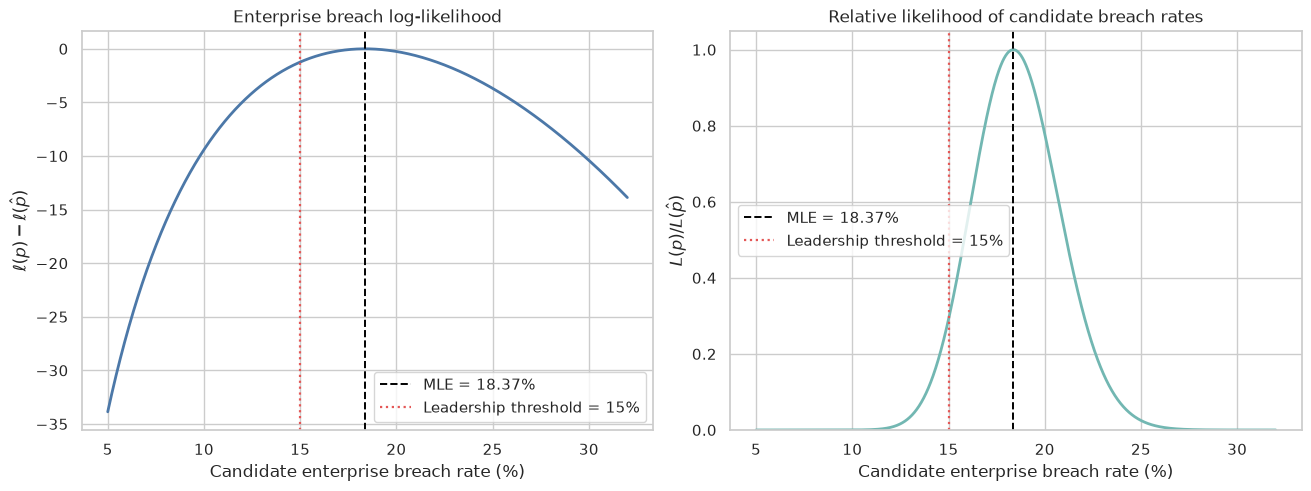

In [3]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
y_enterprise = enterprise_audit['sla_breach'].to_numpy()
p_grid = np.linspace(0.05, 0.32, 2_000)
loglik_grid = bernoulli_loglik(p_grid, y_enterprise)
centered_loglik = loglik_grid - loglik_grid.max()
rel_like = relative_likelihood(loglik_grid)

candidate_ps = [0.12, 0.15, enterprise_phat, 0.20, 0.23]
candidate_table = pd.DataFrame(
    [
        {
            'candidate_breach_rate': f"{100 * p:0.1f}%",
            'centered_log_likelihood': f"{bernoulli_loglik(p, y_enterprise) - loglik_grid.max():0.3f}",
            'relative_likelihood': f"{np.exp(bernoulli_loglik(p, y_enterprise) - loglik_grid.max()):0.3f}",
        }
        for p in candidate_ps
    ]
)
smart_display(candidate_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

axes[0].plot(100 * p_grid, centered_loglik, color='#4C78A8', linewidth=2)
axes[0].axvline(100 * enterprise_phat, color='black', linestyle='--', linewidth=1.4, label=f"MLE = {100 * enterprise_phat:0.2f}%")
axes[0].axvline(15, color='#E45756', linestyle=':', linewidth=1.6, label='Leadership threshold = 15%')
axes[0].set_title('Enterprise breach log-likelihood')
axes[0].set_xlabel('Candidate enterprise breach rate (%)')
axes[0].set_ylabel(r'$\ell(p) - \ell(\hat{p})$')
axes[0].legend()

axes[1].plot(100 * p_grid, rel_like, color='#72B7B2', linewidth=2)
axes[1].axvline(100 * enterprise_phat, color='black', linestyle='--', linewidth=1.4, label=f"MLE = {100 * enterprise_phat:0.2f}%")
axes[1].axvline(15, color='#E45756', linestyle=':', linewidth=1.6, label='Leadership threshold = 15%')
axes[1].set_title('Relative likelihood of candidate breach rates')
axes[1].set_xlabel('Candidate enterprise breach rate (%)')
axes[1].set_ylabel(r'$L(p) / L(\hat{p})$')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.show()

A few points matter here.

- The likelihood curve peaks at the observed enterprise breach rate because the sample proportion is the MLE under the Bernoulli model.
- Likelihood is comparative. A value such as $p = 0.15$ is not judged in isolation; it is judged relative to the best-supported value.
- The shape of the curve matters as much as the peak. A very flat curve would mean the data do not distinguish nearby breach rates strongly. A sharp curve means the evidence is more concentrated.

For decision work, that last point is critical. Stakeholders often want a yes-or-no answer, but the likelihood curve reminds us that the sample usually supports a **region** of nearby values more naturally than a single exact number.

## 3. Likelihood Ratios and a First Look at Model-Based Uncertainty

Likelihood ratios provide a native scale for comparing parameter values. If

$$
\frac{L(p_1)}{L(p_2)} = 0.30,
$$

then $p_1$ has only 30% of the support that $p_2$ has under the model and the observed data.

A second useful quantity is the likelihood-ratio statistic

$$
2\{\ell(\hat{p}) - \ell(p)\}.
$$

Under standard regularity conditions, Wilks' theorem says that this statistic is approximately $\chi^2_1$ when the candidate value is correct and the sample is sufficiently regular (Wilks, 1938). That provides a bridge between likelihood shape and approximate uncertainty sets.

,quantity,value
0,MLE for enterprise breach rate,18.37%
1,Relative likelihood of 15% threshold,0.291
2,Likelihood-ratio statistic for 15% threshold,2.470
3,Approximate 95% profile-likelihood interval,"[14.24%, 23.05%]"


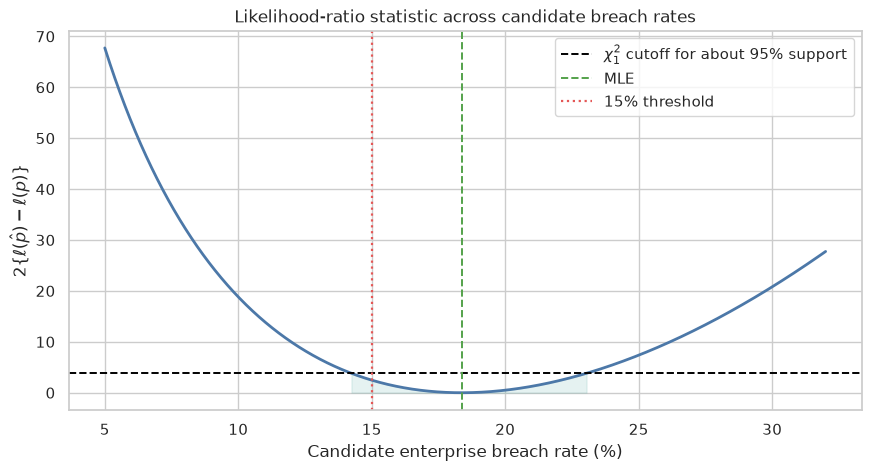

In [4]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
chi2_cutoff_95 = 3.841458820694124
lr_statistic = 2 * (loglik_grid.max() - loglik_grid)
profile_mask = lr_statistic <= chi2_cutoff_95
profile_low = p_grid[profile_mask][0]
profile_high = p_grid[profile_mask][-1]

threshold_p = 0.15
threshold_ll = bernoulli_loglik(threshold_p, y_enterprise)
threshold_rel_like = np.exp(threshold_ll - loglik_grid.max())
threshold_lr = 2 * (loglik_grid.max() - threshold_ll)

likelihood_summary = pd.DataFrame(
    [
        {
            'quantity': 'MLE for enterprise breach rate',
            'value': f"{100 * enterprise_phat:0.2f}%",
        },
        {
            'quantity': 'Relative likelihood of 15% threshold',
            'value': f"{threshold_rel_like:0.3f}",
        },
        {
            'quantity': 'Likelihood-ratio statistic for 15% threshold',
            'value': f"{threshold_lr:0.3f}",
        },
        {
            'quantity': 'Approximate 95% profile-likelihood interval',
            'value': f"[{100 * profile_low:0.2f}%, {100 * profile_high:0.2f}%]",
        },
    ]
)
smart_display(likelihood_summary)

fig, ax = plt.subplots(figsize=(8.6, 4.6), constrained_layout=True)
ax.plot(100 * p_grid, lr_statistic, color='#4C78A8', linewidth=2)
ax.axhline(chi2_cutoff_95, color='black', linestyle='--', linewidth=1.4, label=r'$\chi^2_1$ cutoff for about 95% support')
ax.axvline(100 * enterprise_phat, color='#54A24B', linestyle='--', linewidth=1.4, label='MLE')
ax.axvline(15, color='#E45756', linestyle=':', linewidth=1.6, label='15% threshold')
ax.fill_between(100 * p_grid, 0, lr_statistic, where=profile_mask, color='#72B7B2', alpha=0.18)
ax.set_title('Likelihood-ratio statistic across candidate breach rates')
ax.set_xlabel('Candidate enterprise breach rate (%)')
ax.set_ylabel(r'$2\{\ell(\hat{p}) - \ell(p)\}$')
ax.legend()
plt.show()

This is a useful moment to be nuanced.

- The sample does **not** most strongly support a breach rate below 15%; the MLE is higher.
- But the 15% threshold is not wildly incompatible with the data either. Its relative likelihood is materially below the peak, yet it still falls inside the broad 95% profile-likelihood support region.
- That means the data do not justify a confident claim that the true enterprise breach rate is safely below 15%.

This is exactly the kind of conclusion a good analyst should be comfortable delivering: the threshold is still plausible, but it is **not the value best supported by the evidence**.

## 4. A Normal Likelihood for Resolution Time

Likelihood is not restricted to binary outcomes. Suppose we model ticket resolution times as

$$
Y_i \stackrel{\text{iid}}{\sim} N(\mu, \sigma^2).
$$

Then, up to an additive constant, the log-likelihood is

$$
\ell(\mu, \sigma) = -n \log \sigma - \frac{1}{2\sigma^2}\sum_{i=1}^n (Y_i - \mu)^2.
$$

Under this model, the MLEs are

$$
\hat{\mu}_{\text{MLE}} = \bar{Y},
\qquad
\hat{\sigma}_{\text{MLE}} = \sqrt{\frac{1}{n}\sum_{i=1}^n (Y_i - \bar{Y})^2}.
$$

Notice the denominator $n$, not $n-1$. That is a classic point of confusion. The MLE optimizes the model likelihood; the familiar $n-1$ denominator instead comes from an unbiasedness criterion for variance estimation.

,quantity,value
0,Normal-model MLE for mean,37.33 minutes
1,Normal-model MLE for sigma,18.88 minutes
2,Sample standard deviation with $n-1$,18.89 minutes


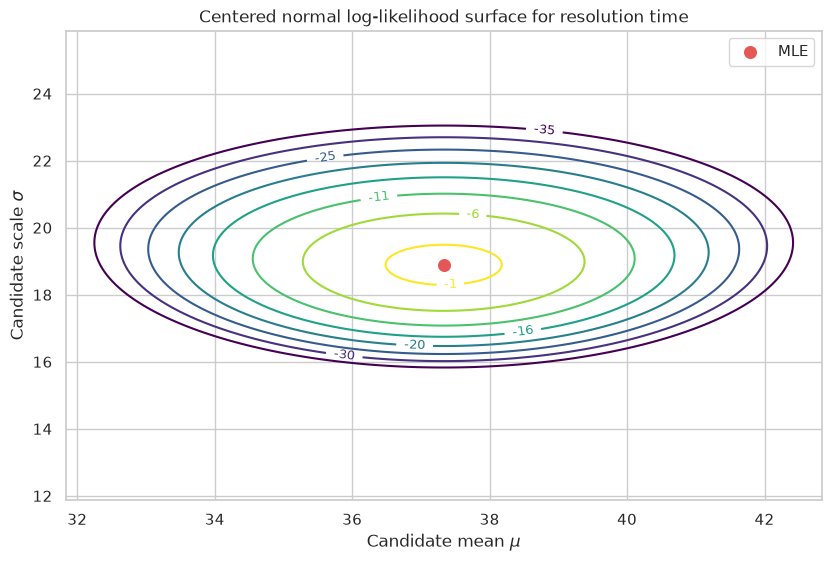

In [5]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
resolution = audit_sample['resolution_minutes'].to_numpy()
mu_mle = resolution.mean()
sigma_mle = resolution.std(ddof=0)
sigma_unbiased = resolution.std(ddof=1)

normal_summary = pd.DataFrame(
    [
        {
            'quantity': 'Normal-model MLE for mean',
            'value': f"{mu_mle:0.2f} minutes",
        },
        {
            'quantity': 'Normal-model MLE for sigma',
            'value': f"{sigma_mle:0.2f} minutes",
        },
        {
            'quantity': 'Sample standard deviation with $n-1$',
            'value': f"{sigma_unbiased:0.2f} minutes",
        },
    ]
)
smart_display(normal_summary)

mu_grid = np.linspace(mu_mle - 5.5, mu_mle + 5.5, 170)
sigma_grid = np.linspace(max(8, sigma_mle - 7), sigma_mle + 7, 160)
MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)

n_obs = len(resolution)
sum_y = resolution.sum()
sum_y2 = np.square(resolution).sum()
sse = sum_y2 - 2 * MU * sum_y + n_obs * MU**2
loglik_surface = -n_obs * np.log(SIGMA) - 0.5 * sse / (SIGMA**2) - 0.5 * n_obs * np.log(2 * np.pi)
centered_surface = loglik_surface - loglik_surface.max()

fig, ax = plt.subplots(figsize=(8.2, 5.5), constrained_layout=True)
contours = ax.contour(MU, SIGMA, centered_surface, levels=np.linspace(-35, -1, 8), cmap='viridis')
ax.clabel(contours, inline=True, fontsize=9, fmt='%0.0f')
ax.scatter([mu_mle], [sigma_mle], color='#E45756', s=70, zorder=3, label='MLE')
ax.set_title('Centered normal log-likelihood surface for resolution time')
ax.set_xlabel(r'Candidate mean $\mu$')
ax.set_ylabel(r'Candidate scale $\sigma$')
ax.legend()
plt.show()

This contour map gives a two-parameter version of the earlier Bernoulli likelihood curve.

- The peak marks the joint MLE for $(\mu, \sigma)$.
- The contours show how quickly support falls off as we move away from that peak.
- The steeper the contours, the more sharply the data discriminate among nearby parameter combinations.

The comparison between $\hat{\sigma}_{\text{MLE}}$ and the usual sample standard deviation is also pedagogically important. MLE is not trying to be unbiased in finite samples. It is trying to maximize the probability density assigned to the observed data under the chosen model.

## 5. Identifiability Versus Information: Same Estimate, Very Different Evidence

Two ideas are easy to blur together.

- **Identifiability** asks whether different parameter values imply genuinely different distributions. In the Bernoulli model, distinct values of $p$ do imply distinct data distributions, so the model is identifiable.
- **Information content** asks how sharply the observed data distinguish among those parameter values.

A model can be identifiable and still yield a broad likelihood if the sample is small or weakly informative. To see that, compare two hypothetical audits with the same estimated breach rate $\hat{p} = 0.20$ but very different sample sizes.

,scenario,sample_size,breaches,MLE,approximate_95_profile_interval
0,Small audit,20,4,20.0%,"[6.7%, 40.5%]"
1,Large audit,200,40,20.0%,"[14.9%, 25.9%]"


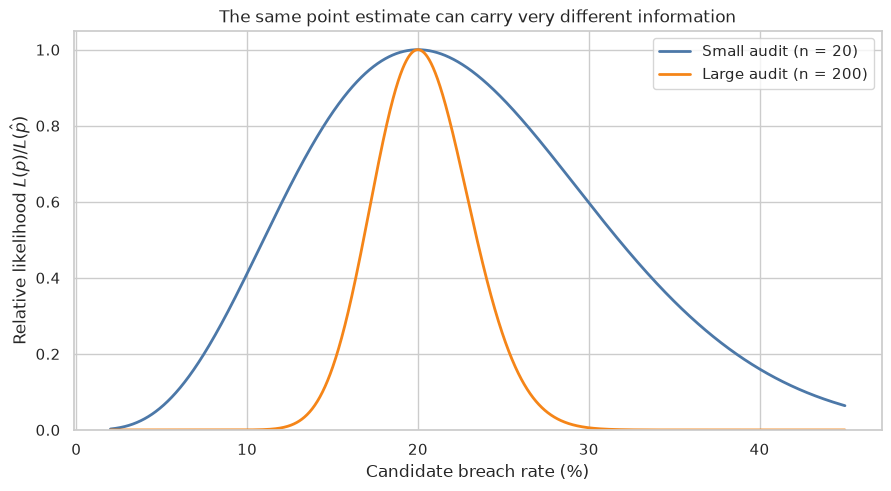

In [6]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
p_compare = np.linspace(0.02, 0.45, 2_000)
scenarios = [
    {'label': 'Small audit', 'n': 20, 'x': 4, 'color': '#4C78A8'},
    {'label': 'Large audit', 'n': 200, 'x': 40, 'color': '#F58518'},
]

comparison_rows = []
fig, ax = plt.subplots(figsize=(8.8, 4.8), constrained_layout=True)

for scenario in scenarios:
    n_s = scenario['n']
    x_s = scenario['x']
    phat_s = x_s / n_s
    ll_s = x_s * np.log(np.clip(p_compare, 1e-9, 1 - 1e-9)) + (n_s - x_s) * np.log(np.clip(1 - p_compare, 1e-9, 1 - 1e-9))
    rel_s = np.exp(ll_s - ll_s.max())
    lr_s = 2 * (ll_s.max() - ll_s)
    mask_s = lr_s <= chi2_cutoff_95
    interval_s = (p_compare[mask_s][0], p_compare[mask_s][-1])

    comparison_rows.append(
        {
            'scenario': scenario['label'],
            'sample_size': n_s,
            'breaches': x_s,
            'MLE': f"{100 * phat_s:0.1f}%",
            'approximate_95_profile_interval': f"[{100 * interval_s[0]:0.1f}%, {100 * interval_s[1]:0.1f}%]",
        }
    )

    ax.plot(100 * p_compare, rel_s, color=scenario['color'], linewidth=2, label=f"{scenario['label']} (n = {n_s})")

smart_display(pd.DataFrame(comparison_rows))
ax.set_title('The same point estimate can carry very different information')
ax.set_xlabel('Candidate breach rate (%)')
ax.set_ylabel(r'Relative likelihood $L(p)/L(\hat{p})$')
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

This comparison is one of the cleanest illustrations of what likelihood contributes.

Both hypothetical audits produce the same MLE, 20%. If we reported only the point estimate, they would look equivalent. But the larger audit generates a much more concentrated likelihood and a much narrower support region. In other words, it carries far more information.

This is why good statistical reporting cannot stop at the estimate alone. Likelihood shape, or some faithful summary of it, tells us how much confidence we should have in nearby alternatives.

## 6. Model Misspecification: A Useful Likelihood Can Still Be Wrong in Detail

Likelihood is always conditional on a model. If the model is poorly matched to the data-generating process, the MLE is optimizing the wrong target.

That does **not** make the procedure useless. It means we should interpret the result appropriately. Under misspecification, maximum likelihood can still converge to the parameter values that give the best approximation within the chosen family (White, 1982), but those parameter values need not describe the data literally.

The normal model for resolution times is a good example. Ticket times are bounded below, somewhat right-skewed, and operationally heterogeneous. A normal likelihood may still summarize center and spread effectively, but it will generally assign some probability to impossible or unrealistic regions.

,event,empirical_frequency,normal_model_prediction
0,P(Y < 0),0.00%,2.40%
1,P(Y < 5),0.00%,4.34%
2,P(Y > 60),13.50%,11.49%
3,P(Y > 75),3.50%,2.30%


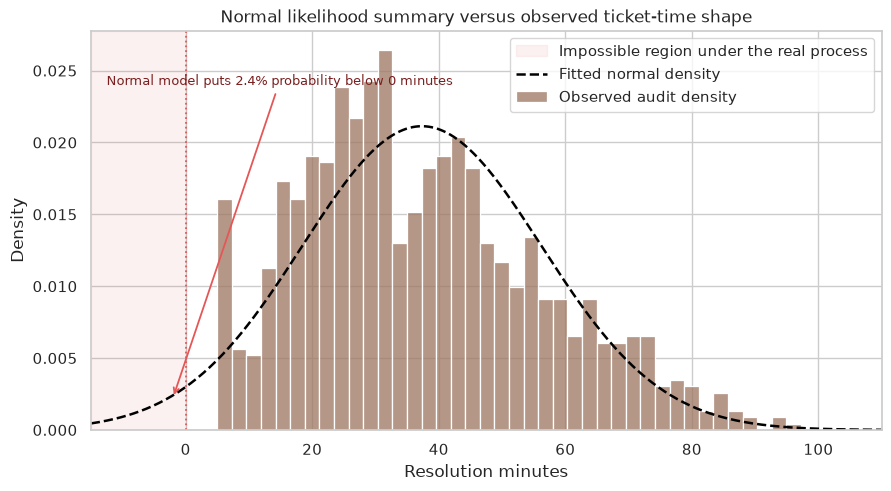

In [7]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
x = np.linspace(-15, max(110, resolution.max() + 5), 500)

negative_mass = normal_lower_tail(0, mu_mle, sigma_mle)

misspec_rows = []
for label, empirical, model in [
    ('P(Y < 0)', 0.0, negative_mass),
    ('P(Y < 5)', np.mean(resolution < 5), normal_lower_tail(5, mu_mle, sigma_mle)),
    ('P(Y > 60)', np.mean(resolution > 60), normal_upper_tail(60, mu_mle, sigma_mle)),
    ('P(Y > 75)', np.mean(resolution > 75), normal_upper_tail(75, mu_mle, sigma_mle)),
]:
    misspec_rows.append(
        {
            'event': label,
            'empirical_frequency': f"{100 * empirical:0.2f}%",
            'normal_model_prediction': f"{100 * model:0.2f}%",
        }
    )

misspec_table = pd.DataFrame(misspec_rows)
smart_display(misspec_table)

fig, ax = plt.subplots(figsize=(8.8, 4.8), constrained_layout=True)
ax.axvspan(-15, 0, color='#E45756', alpha=0.08, label='Impossible region under the real process')
ax.axvline(0, color='#E45756', linestyle=':', linewidth=1.3)
sns.histplot(resolution, bins=40, stat='density', color='#9C755F', alpha=0.75, ax=ax, label='Observed audit density')
ax.plot(x, normal_pdf(x, mu_mle, sigma_mle), color='black', linestyle='--', linewidth=1.8, label='Fitted normal density')
ax.annotate(
    f"Normal model puts {100 * negative_mass:0.1f}% probability below 0 minutes",
    xy=(-2, normal_pdf(0, mu_mle, sigma_mle) * 0.75),
    xytext=(-12.5, 0.024),
    arrowprops={'arrowstyle': '->', 'color': '#E45756', 'lw': 1.3},
    fontsize=9.5,
    color='#7A1F1F',
)
ax.set_title('Normal likelihood summary versus observed ticket-time shape')
ax.set_xlabel('Resolution minutes')
ax.set_ylabel('Density')
ax.set_xlim(-15, max(110, resolution.max() + 5))
ax.legend()
plt.show()

This is the right stance toward model-based inference: respectful, but not naive.

The fitted normal model captures the broad center of the audit reasonably well, which is why the normal likelihood can still be operationally useful. But it also implies impossible negative resolution times and does not exactly match the right tail. The shaded region to the left of zero makes that concrete: the fitted normal model allocates nonzero probability to outcomes that cannot happen. That mismatch is not a bug in the code; it is a reminder that statistical models are approximations.

A professional analyst should therefore separate two claims:

1. The likelihood summary is informative within the assumed model.
2. The assumed model should still be checked against the qualitative behavior of the data.

That second claim is one of the reasons later notebooks will focus on interval comparisons, model checking, and robustness.

## 7. Likelihood-Based Decision Memo

Suppose leadership wants to market a premium enterprise support promise, but only if the enterprise SLA breach rate is credibly below 15%.

A likelihood-oriented analyst should not reduce this to a single estimate alone. The relevant evidence includes the MLE, the support assigned to the 15% threshold, and the width of the likelihood-supported region around the MLE.

In [8]:
# Translate the computed evidence into a decision-oriented summary.
if enterprise_phat < 0.15 and profile_high < 0.15:
    recommendation = 'Proceed with the premium enterprise support promise.'
    interpretation = 'Both the best-supported rate and the broader likelihood-supported region remain below the policy threshold.'
elif enterprise_phat < 0.15:
    recommendation = 'Continue the pilot before making a stronger public promise.'
    interpretation = 'The best-supported rate is below the threshold, but the likelihood-supported region still extends above it.'
else:
    recommendation = 'Do not advertise a sub-15% enterprise breach promise yet.'
    interpretation = 'The MLE is above the threshold, and the values most supported by the data are centered above the leadership target even though 15% is not impossible.'

memo = (
    f"### Decision Memo\n\n"
    f"**Recommendation:** {recommendation}\n\n"
    f"**Observed evidence:**\n\n"
    f"- Enterprise tickets audited: **{enterprise_n}**\n"
    f"- Enterprise breaches observed: **{enterprise_breach_count}**\n"
    f"- Maximum likelihood estimate of enterprise breach risk: **{100 * enterprise_phat:0.2f}%**\n"
    f"- Relative likelihood of the leadership threshold $p = 15\\%$: **{threshold_rel_like:0.3f}**\n"
    f"- Approximate 95% profile-likelihood interval: **[{100 * profile_low:0.2f}%, {100 * profile_high:0.2f}%]**\n\n"
    f"**Interpretation:** {interpretation}\n\n"
    f"The data still leave some support for a 15% breach rate, but that is not where the likelihood peaks. A careful analyst would therefore avoid presenting the threshold as already established and would instead frame the current result as evidence for continued monitoring or process improvement before scaling the promise."
)

display(Markdown(memo))

### Decision Memo

**Recommendation:** Do not advertise a sub-15% enterprise breach promise yet.

**Observed evidence:**

- Enterprise tickets audited: **294**
- Enterprise breaches observed: **54**
- Maximum likelihood estimate of enterprise breach risk: **18.37%**
- Relative likelihood of the leadership threshold $p = 15\%$: **0.291**
- Approximate 95% profile-likelihood interval: **[14.24%, 23.05%]**

**Interpretation:** The MLE is above the threshold, and the values most supported by the data are centered above the leadership target even though 15% is not impossible.

The data still leave some support for a 15% breach rate, but that is not where the likelihood peaks. A careful analyst would therefore avoid presenting the threshold as already established and would instead frame the current result as evidence for continued monitoring or process improvement before scaling the promise.

<!-- real-data-companion-course01 -->
## Real-Data Companion: Likelihood for Medical-Visit Counts

RAND HIE outpatient visits are count data, which makes the dataset a natural companion for likelihood thinking. A likelihood is not just a fitting device. It is a model-based claim about which outcome values are plausible, how dispersion behaves, and how the data should influence parameter estimates.

The unit is a person-period record and the outcome is `mdvis`, the number of outpatient physician visits. Visit counts often have many small values and a long right tail, so a simple Poisson model can be too restrictive if the variance is much larger than the mean.

The companion compares a Poisson count model with a negative-binomial working model. The experiment asks whether the model family respects the empirical dispersion in the real outcome. It is not a full utilization model with every plan and health covariate. It is a likelihood lesson: choose a probability model whose implied data behavior is credible for the measurement scale.

Data source: [RAND Health Insurance Experiment in statsmodels](https://www.statsmodels.org/stable/datasets/generated/randhie.html).

,model,log_likelihood,aic,pearson_dispersion
0,Poisson,-62641.672000,125301.344000,6.300000
1,Negative binomial working model,-43616.844000,87251.688000,1.707000


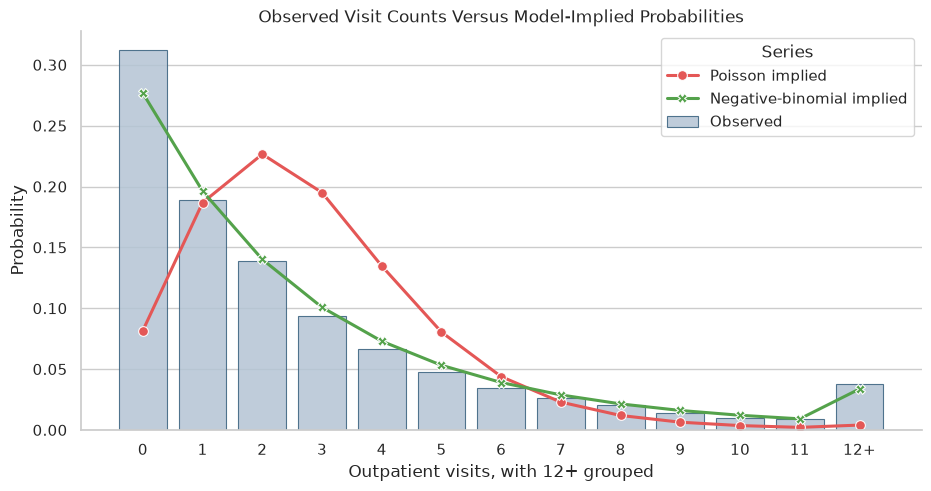

In [9]:
# real-data-companion-course01
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import nbinom, poisson
import seaborn as sns
import statsmodels.api as sm


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_randhie, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    rand_hie = load_statsmodels_randhie().copy()
    predictors = ["lncoins", "idp", "lpi", "physlm", "disea", "hlthg", "hlthf", "hlthp"]
    X = sm.add_constant(rand_hie[predictors])
    y = rand_hie["mdvis"]

    poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()
    nb_model = sm.GLM(y, X, family=sm.families.NegativeBinomial(alpha=1.0)).fit()

    comparison = pd.DataFrame(
        [
            {
                "model": "Poisson",
                "log_likelihood": poisson_model.llf,
                "aic": poisson_model.aic,
                "pearson_dispersion": poisson_model.pearson_chi2 / poisson_model.df_resid,
            },
            {
                "model": "Negative binomial working model",
                "log_likelihood": nb_model.llf,
                "aic": nb_model.aic,
                "pearson_dispersion": nb_model.pearson_chi2 / nb_model.df_resid,
            },
        ]
    )
    smart_display(comparison.round(3))

    # Compare the empirical count distribution with the probability mass implied by each fitted likelihood.
    # The final bin groups all values 12 and above so the tail remains visible without crowding the axis.
    max_count = 12
    count_values = np.arange(max_count + 1)
    count_labels = [str(k) for k in range(max_count)] + [f"{max_count}+"]
    observed_probabilities = (
        y.clip(upper=max_count)
        .value_counts(normalize=True)
        .reindex(count_values, fill_value=0.0)
        .sort_index()
    )

    poisson_mu = poisson_model.fittedvalues.to_numpy()
    nb_mu = nb_model.fittedvalues.to_numpy()
    alpha = nb_model.model.family.alpha
    nb_size = 1 / alpha
    nb_success_probability = nb_size / (nb_size + nb_mu)

    probability_rows = []
    for visit_count, label in zip(count_values, count_labels):
        probability_rows.append(
            {
                "series": "Observed",
                "visit_count": visit_count,
                "visit_bin": label,
                "probability": observed_probabilities.loc[visit_count],
            }
        )

        if visit_count < max_count:
            poisson_probability = poisson.pmf(visit_count, poisson_mu).mean()
            nb_probability = nbinom.pmf(visit_count, nb_size, nb_success_probability).mean()
        else:
            poisson_probability = poisson.sf(max_count - 1, poisson_mu).mean()
            nb_probability = nbinom.sf(max_count - 1, nb_size, nb_success_probability).mean()

        probability_rows.extend(
            [
                {
                    "series": "Poisson implied",
                    "visit_count": visit_count,
                    "visit_bin": label,
                    "probability": poisson_probability,
                },
                {
                    "series": "Negative-binomial implied",
                    "visit_count": visit_count,
                    "visit_bin": label,
                    "probability": nb_probability,
                },
            ]
        )

    count_probabilities = pd.DataFrame(probability_rows)

    fig, ax = plt.subplots(figsize=(9.2, 4.8), constrained_layout=True)
    sns.barplot(
        data=count_probabilities.query("series == 'Observed'"),
        x="visit_count",
        y="probability",
        color="#AFC4D9",
        edgecolor="#365F7D",
        linewidth=0.8,
        alpha=0.85,
        ax=ax,
        label="Observed",
    )
    sns.lineplot(
        data=count_probabilities.query("series != 'Observed'"),
        x="visit_count",
        y="probability",
        hue="series",
        style="series",
        markers=True,
        dashes=False,
        linewidth=2.2,
        markersize=7,
        palette={"Poisson implied": "#E45756", "Negative-binomial implied": "#54A24B"},
        ax=ax,
    )
    ax.set_title("Observed Visit Counts Versus Model-Implied Probabilities")
    ax.set_xlabel("Outpatient visits, with 12+ grouped")
    ax.set_ylabel("Probability")
    ax.set_xticks(count_values)
    ax.set_xticklabels(count_labels)
    ax.legend(title="Series", frameon=True, loc="upper right")
    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note("RAND HIE real-data companion skipped because RUN_REAL_DATA_COMPANION is False.")


<!-- real-data-companion-course01 -->
No likelihood family wins by name alone. Likelihood-based inference inherits the assumptions of the probability model. When the count outcome has more variation than a Poisson model expects, standard errors, intervals, and prediction intervals can become too confident unless the model is adjusted or checked carefully.

## 8. What to Remember

1. Likelihood treats the observed data as fixed and ranks parameter values according to how well they explain those data under the model.
2. In the Bernoulli case, the sample proportion is the MLE because it maximizes the observed-data likelihood.
3. The shape of the likelihood matters: sharp likelihoods indicate concentrated evidence, while flat likelihoods indicate weak discrimination among nearby parameter values.
4. Identifiability is about whether distinct parameter values imply distinct distributions; information is about how strongly the observed sample distinguishes those values.
5. For the normal model, the MLE for the scale parameter uses the denominator $n$ because it follows from likelihood optimization with the unbiasedness criterion treated separately.
6. Likelihood-based conclusions inherit the strengths and weaknesses of the chosen model family.
7. Good decision writing uses likelihood to express evidence carefully while avoiding the impression that a single threshold has established certainty.

The next notebook builds directly on this one by comparing several families of interval estimators: Wald intervals, likelihood-based intervals, and bootstrap intervals.

## References

- Fisher, R. A. (1922). *On the mathematical foundations of theoretical statistics*. *Philosophical Transactions of the Royal Society of London. Series A, 222*, 309-368. [https://doi.org/10.1098/rsta.1922.0009](https://doi.org/10.1098/rsta.1922.0009)
- Myung, I. J. (2003). *Tutorial on maximum likelihood estimation*. *Journal of Mathematical Psychology, 47*(1), 90-100. [https://doi.org/10.1016/S0022-2496(02)00028-7](https://doi.org/10.1016/S0022-2496%2802%2900028-7)
- White, H. (1982). *Maximum likelihood estimation of misspecified models*. *Econometrica, 50*(1), 1-25. [https://doi.org/10.2307/1912526](https://doi.org/10.2307/1912526)
- Wilks, S. S. (1938). *The large-sample distribution of the likelihood ratio for testing composite hypotheses*. *The Annals of Mathematical Statistics, 9*(1), 60-62. [https://doi.org/10.1214/aoms/1177732360](https://doi.org/10.1214/aoms/1177732360)